# Plot zonal annual mean NOy

---

Create date: 2026-01-05

## Motivation

Plot zonal mean of all stratospheric heterogeneous reactions from ACSIS simulation to identify if any of the heterogeneous reactions that should only be activated in the stratosphere is activated in the troposphere.


In [ ]:
import xarray as xr
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# modules from this directory
sys.path.append("../../")
import src.const as CONST
from src.util.load_data import load_um_data

In [ ]:
stashes = [
    "50551",
    "50552",
    "50553",
    "50554",
    "50555",
]

data_path = "/work/scratch-pw2/vs480/nc_files/u-bv828"

In [ ]:
datasets = {}

datasets["exp11"] = load_um_data(
    data_path=data_path,
    stash_list=stashes,
    engine="netcdf4",
)

Loading files from /work/scratch-pw2/vs480/nc_files/u-bv828 with stashes ['50551', '50552', '50553', '50554', '50555']


## 1. prepare dataset

Rename stashes


In [35]:
rename_dict = {
    # "m01s50i290": "bimol85_1",
    # "m01s50i291": "het4",
    # "m01s50i654": "bimol85_2",
    # "m01s50i873": "drydep",
    # "m01s50i914": "wetdep",
    "m01s50i551": "het01",
    "m01s50i552": "het02",
    "m01s50i553": "het03",
    "m01s50i554": "het04",
    "m01s50i555": "het05",
}

het_dict = {
    "het01": "ClONO2 + H2O -> HOCl + HNO3",
    "het02": "ClONO2 + HCl -> Cl + Cl",
    "het03": "HOCl + HCl -> Cl + Cl",
    "het04": "N2O5 + H2O -> HNO3 + HNO3",
    "het05": "N2O5 + HCl -> Cl + NO2",
}

In [11]:
for d, dataset in datasets.items():
    datasets[d] = datasets[d].rename(rename_dict)

In [15]:
fluxes = ["het01", "het02", "het03", "het04", "het05"]

timeslices = {1983: slice("1983-01-01", "2001-12-31")}

In [16]:
datasets_zonal = {d: xr.Dataset() for d in datasets.keys()}

In [24]:
# Flux unit: moles/gridbox/s

In [53]:
time = timeslices[1983]
m_n2o5 = 108.01e-3
for d, dataset in datasets.items():
    for variable in fluxes:
        datasets_zonal[d][f"{variable}_rate"] = (
            dataset[variable].sel(time=time).sum(dim=["lon"]).mean(dim="time").load()
        )  # mol/s

In [54]:
def create_custom_subplots(
    fig_width, widths_subplot, heights_subplot, exclude_bottom_rows: int = 0
):

    fig = plt.figure(figsize=(fig_width, 0.7 * fig_width))

    nrow = len(heights_subplot)
    ncol = len(widths_subplot)

    gs = fig.add_gridspec(
        nrow, ncol, width_ratios=widths_subplot, height_ratios=heights_subplot
    )

    if nrow - exclude_bottom_rows < 0:
        raise ValueError("nrow < 0")

    axs = [
        fig.add_subplot(gs[i, j])
        for i in range(nrow - exclude_bottom_rows)
        for j in range(ncol)
    ]

    return fig, axs, gs, nrow, ncol

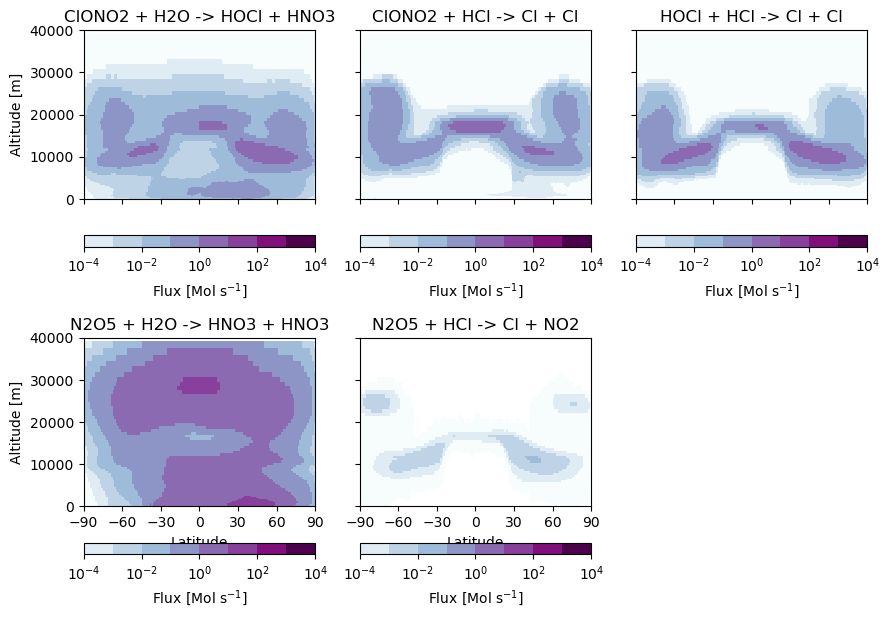

In [59]:
d = "exp11"

fig, axs, gs, nrow, ncol = create_custom_subplots(
    fig_width=9,
    widths_subplot=[1, 1, 1],
    heights_subplot=[1, 1],
    exclude_bottom_rows=0,
)
variables = ["het01_rate", "het02_rate", "het03_rate", "het04_rate", "het05_rate"]
for ax, variable in zip(axs, variables):
    datasets_zonal[d][variable].plot(
        ax=ax,
        y="level_height",
        cmap=plt.cm.BuPu,
        norm=colors.LogNorm(),
        vmin=1e-4,
        vmax=1e4,
        cbar_kwargs={
            "orientation": "horizontal",
            "label": "Flux [Mol s$^{-1}$]",
            "extend": "neither",
        },
        levels=9,
    )
    v = variable.split("_")[0]
    ax.set_title(het_dict[v])
    ax.set_ylim(0, 40000)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Altitude [m]")

for ax in axs[:-ncol]:
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.set_xlabel("")

for ax in axs[1::ncol] + axs[2::ncol]:
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.set_ylabel("")

axs[5].remove()

fig.tight_layout()